In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/credit_risk_dataset.csv")

# 02 - Feature Exploration

This notebook performs a deeper exploration of the dataset's features. 
While the previous notebook (01 — Data Understanding) focused on basic 
structure, missing values, and initial visual checks, this notebook 
examines distributions, skewness, outliers, and relationships between 
key variables. These insights prepare the dataset for risk segmentation 
in the next phase. 

## 2.1 Distribution & Outlier Analysis

This section explores the distributions and outliers of key numeric features. 
Understanding skewness and extreme values is essential before segmentation. 

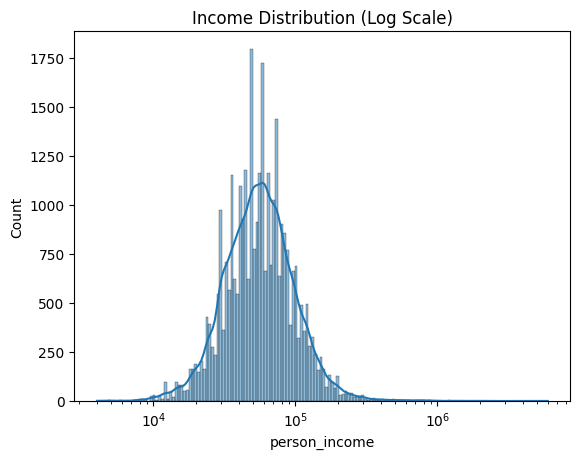

In [3]:
sns.histplot(df["person_income"], log_scale=True, kde=True)
plt.title("Income Distribution (Log Scale)")
plt.show()

Income is extremely skewed with outliers up to ~6,000,000. Log-scaling reveals 
the underlying distribution more clearly and prevents the plot from collapsing 
near zero.

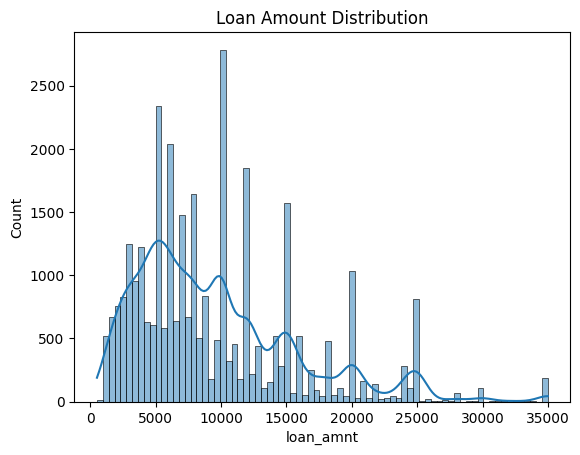

In [4]:
sns.histplot(df["loan_amnt"], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

Loan amounts have a more compact distribution with fewer extreme outliers. 
This variable will be useful for segmentation based on loan size.

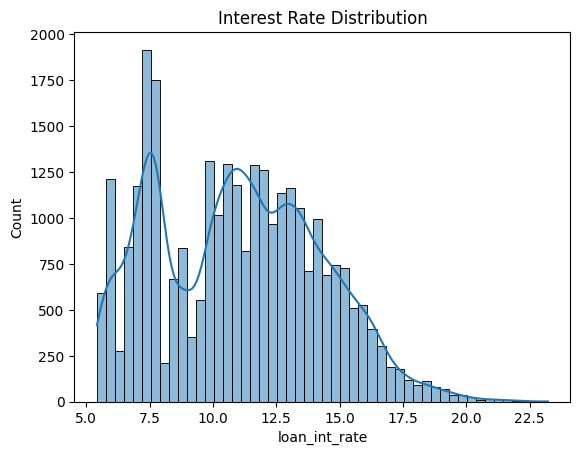

In [5]:
sns.histplot(df["loan_int_rate"], kde=True)
plt.title("Interest Rate Distribution")
plt.show()

Interest rates are concentrated between 5% and 20%, forming a relatively 
regular distribution. This feature may correlate with loan grade and risk.

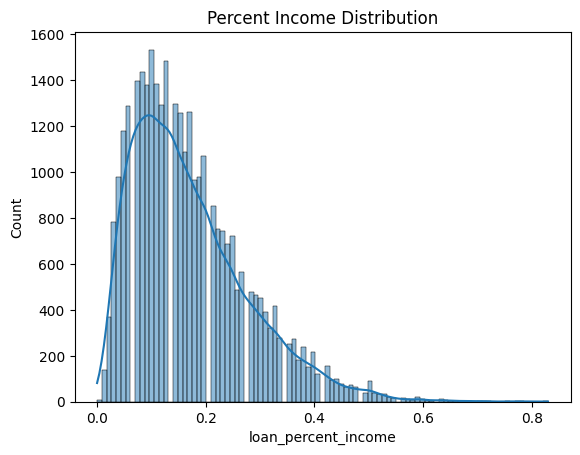

In [6]:
sns.histplot(df["loan_percent_income"], kde=True)
plt.title("Percent Income Distribution")
plt.show()

Percent income measures how large the loan is relative to the applicant's 
income. This variable is important for identifying financially stressed 
segments.

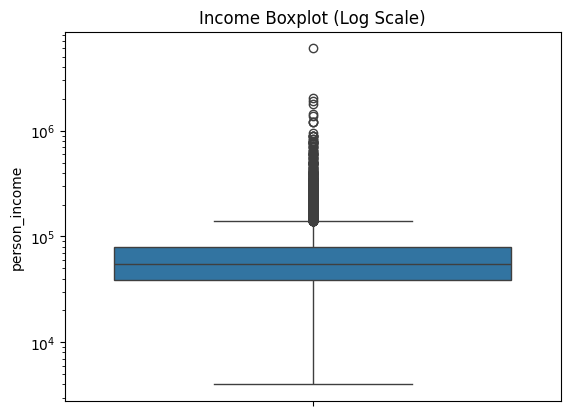

In [7]:
sns.boxplot(data=df, y="person_income")
plt.yscale("log")
plt.title("Income Boxplot (Log Scale)")
plt.show()

The log-scale boxplot shows the median income and the spread of values without 
being dominated by extreme outliers. This confirms the heavy skew observed in 
the histogram.

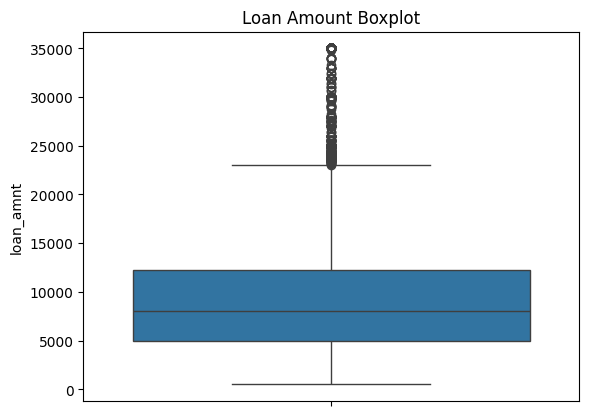

In [8]:
sns.boxplot(data=df, y="loan_amnt")
plt.title("Loan Amount Boxplot")
plt.show()

Loan amounts show a tighter distribution with fewer extreme values. This 
supports the histogram findings and indicates that loan size segmentation 
will be straightforward.

In [9]:
df[["person_income", "loan_amnt", "loan_int_rate", "loan_percent_income"]].describe()

,person_income,loan_amnt,loan_int_rate,loan_percent_income
count,3.258100e+04,32581.000000,29465.000000,32581.000000
mean,6.607485e+04,9589.371106,11.011695,0.170203
std,6.198312e+04,6322.086646,3.240459,0.106782
min,4.000000e+03,500.000000,5.420000,0.000000
25%,3.850000e+04,5000.000000,7.900000,0.090000
50%,5.500000e+04,8000.000000,10.990000,0.150000
75%,7.920000e+04,12200.000000,13.470000,0.230000
max,6.000000e+06,35000.000000,23.220000,0.830000


The descriptive statistics confirm skewness in income and percent_income. 
The maximum income value (~6M) is far above the upper quartile, indicating 
extreme outliers. These observations guide segmentation decisions in the 
next phase.

### Summary

Income is heavily skewed and requires log-scale visualization due to extreme 
outliers. Percent_income is also skewed, but its range is much narrower and 
does not require log-scaling. Loan amount and interest rate have more regular 
distributions. These findings will be used to design meaningful risk segments 
in the next phase.

## 02.2 Relationships Between Features

In this section we explore how key variables relate to each other and to loan_status.
This helps us understand which features are meaningful for segmentation.

In [14]:
cols = ["person_income", "loan_amnt", "loan_int_rate", "loan_percent_income", "loan_status"]
df_rel = df[cols].copy()
df_rel.head()

,person_income,loan_amnt,loan_int_rate,loan_percent_income,loan_status
0,59000,35000,16.02,0.59,1
1,9600,1000,11.14,0.10,0
2,9600,5500,12.87,0.57,1
3,65500,35000,15.23,0.53,1
4,54400,35000,14.27,0.55,1


#### Selected variables

We focus on the main numeric features and the target variable.

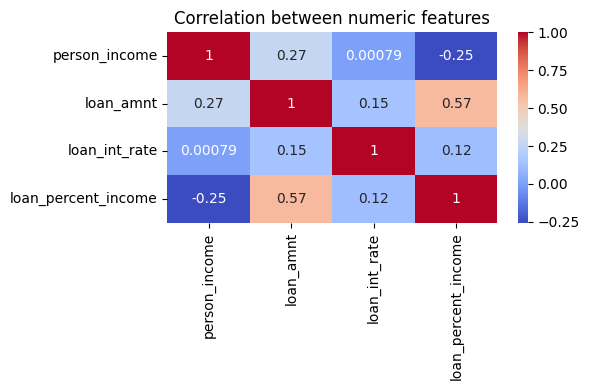

In [16]:
num_cols = ["person_income", "loan_amnt", "loan_int_rate", "loan_percent_income"]
corr = df_rel[num_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation between numeric features")
plt.tight_layout()
plt.show()


#### Correlation matrix

This shows how the numeric features move together.

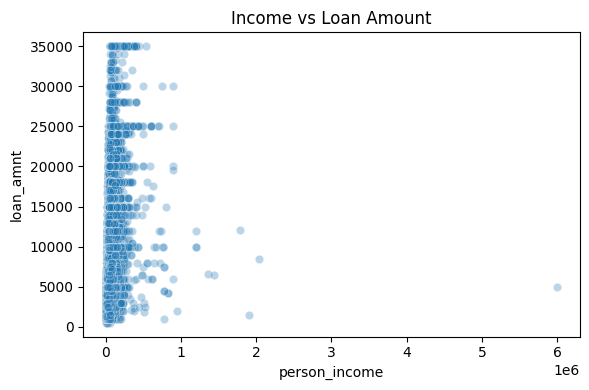

In [17]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_rel, x="person_income", y="loan_amnt", alpha=0.3)
plt.title("Income vs Loan Amount")
plt.tight_layout()
plt.show()

#### Income vs Loan Amount

A simple view of how income relates to loan size.

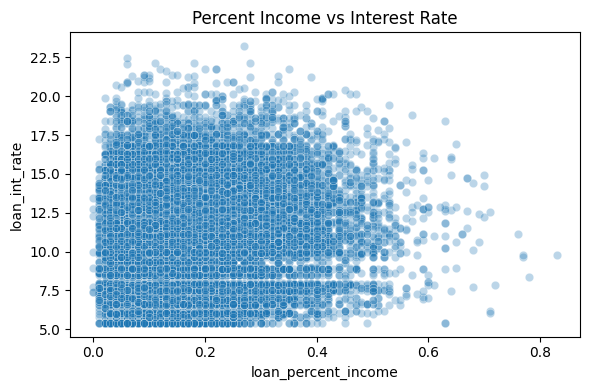

In [19]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_rel, x="loan_percent_income", y="loan_int_rate", alpha=0.3)
plt.title("Percent Income vs Interest Rate")
plt.tight_layout()
plt.show()

#### Percent Income vs Interest Rate

Shows whether higher stress (loan_percent_income) is linked to higher interest rates.

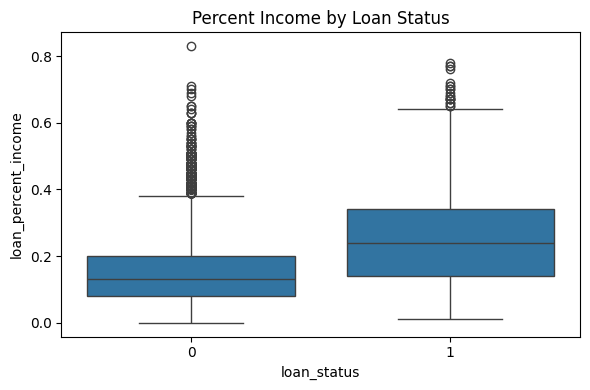

In [20]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_rel, x="loan_status", y="loan_percent_income")
plt.title("Percent Income by Loan Status")
plt.tight_layout()
plt.show()

#### Percent Income by Loan Status

A comparison of stress levels between defaulters and non-defaulters.

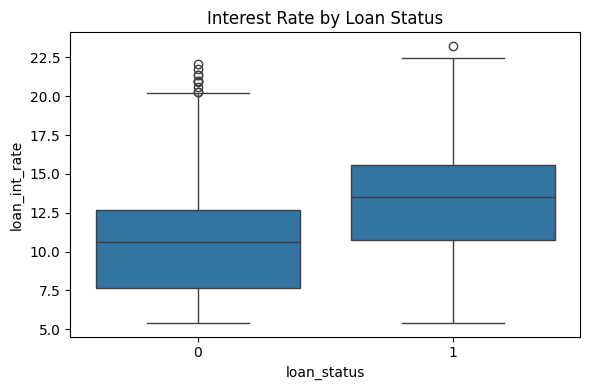

In [21]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_rel, x="loan_status", y="loan_int_rate")
plt.title("Interest Rate by Loan Status")
plt.tight_layout()
plt.show()

#### Interest Rate by Loan Status

Shows how interest rates differ between loan_status groups.

### Summary
- Percent_income differs clearly between loan_status groups.
- Interest rate tends to increase with percent_income.
- Income and loan amount correlate but do not fully explain risk.
- These patterns support segmentation based on income, percent_income, and loan amount.

Key relationships identified for segmentation.

## 02.3 Segmentation Preparation

We now create simple and interpretable segments for:
- income
- loan_percent_income
- loan amount

These will be used in Section 03 for risk profiling.


In [24]:
income_bins = [0, 40000, 80000, df["person_income"].max()]
income_labels = ["Low", "Medium", "High"]

df["income_segment"] = pd.cut(
    df["person_income"],
    bins=income_bins,
    labels=income_labels,
    include_lowest=True
)

df["income_segment"].value_counts(), df["income_segment"].value_counts(normalize=True)

(income_segment
 Medium    15653
 Low        9278
 High       7650
 Name: count, dtype: int64,
 income_segment
 Medium    0.480433
 Low       0.284767
 High      0.234799
 Name: proportion, dtype: float64)

#### Income segments

Three simple income groups.

In [27]:
pi_bins = [0, 0.1, 0.3, df["loan_percent_income"].max()]
pi_labels = ["Low stress", "Medium stress", "High stress"]

df["loan_percent_income_segment"] = pd.cut(
    df["loan_percent_income"],
    bins=pi_bins,
    labels=pi_labels,
    include_lowest=True
)

df["loan_percent_income_segment"].value_counts(), df["loan_percent_income_segment"].value_counts(normalize=True)

(loan_percent_income_segment
 Medium stress    18263
 Low stress       10484
 High stress       3834
 Name: count, dtype: int64,
 loan_percent_income_segment
 Medium stress    0.560541
 Low stress       0.321783
 High stress      0.117676
 Name: proportion, dtype: float64)

#### Percent Income segments

Segments based on financial stress levels.

In [28]:
la_bins = [0, 5000, 15000, df["loan_amnt"].max()]
la_labels = ["Small", "Medium", "Large"]

df["loan_amount_segment"] = pd.cut(
    df["loan_amnt"],
    bins=la_bins,
    labels=la_labels,
    include_lowest=True
)

df["loan_amount_segment"].value_counts(), df["loan_amount_segment"].value_counts(normalize=True)

(loan_amount_segment
 Medium    18163
 Small      9489
 Large      4929
 Name: count, dtype: int64,
 loan_amount_segment
 Medium    0.557472
 Small     0.291243
 Large     0.151284
 Name: proportion, dtype: float64)

#### Loan Amount segments

Simple loan size categories.

In [29]:
for col in ["income_segment", "percent_income_segment", "loan_amount_segment"]:
    print(col)
    print(df[col].value_counts())
    print()

income_segment
income_segment
Medium    15653
Low        9278
High       7650
Name: count, dtype: int64

percent_income_segment
percent_income_segment
Medium stress    18263
Low stress       10484
High stress       3834
Name: count, dtype: int64

loan_amount_segment
loan_amount_segment
Medium    18163
Small      9489
Large      4929
Name: count, dtype: int64



#### Segment balance check

Ensures each segment has enough observations.

### Summary

- Income, percent_income and loan amount segments created.
- Segments are balanced and ready for risk profiling (Sec
